# Student Lifestyle and Depression Prediction Project
## Project Overview
This project aims to analyze student lifestyle factors and build machine learning models to predict whether a student is likely to have depression.

The dataset contains student information such as age, gender ,department, CGPA, Sleep duration, study hours, social media usage, physical activity, stress level and depression status.



## Step 1: Data Loading and First look

In [1]:
import pandas as pd 
import numpy as np

df=pd.read_csv(r"C:\Users\altay\Downloads\archive (9)\student_lifestyle_100k.csv")
df.shape


(100000, 11)

In [2]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration',
       'Study_Hours', 'Social_Media_Hours', 'Physical_Activity',
       'Stress_Level', 'Depression'],
      dtype='str')

In [3]:
df.dtypes

Student_ID              int64
Age                     int64
Gender                    str
Department                str
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object

In [4]:
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## Step 2: Exploratory Data Analysis (EDA)
In this step, we explore the dataset to understand the main patterns, distributions, and relationships between variables.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols=["Age","CGPA","Sleep_Duration","Study_Hours",
          "Social_Media_Hours","Physical_Activity","Stress_Level"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,21.009010,2.000382,18.00,19.00,21.0,23.00,24.0
CGPA,100000.0,2.898316,0.532240,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,6.996425,1.498682,3.00,6.00,7.0,8.00,12.0
Study_Hours,100000.0,4.509517,1.976076,0.00,3.20,4.5,5.80,12.8
Social_Media_Hours,100000.0,3.503288,1.486852,0.00,2.50,3.5,4.50,10.0
Physical_Activity,100000.0,74.353180,43.366963,0.00,37.00,74.0,112.00,149.0
Stress_Level,100000.0,4.131660,1.424151,2.00,3.00,4.0,5.00,10.0


### Statistics Insights

The numrical features have different ranges. for example CGPA has scale between 0 and 4 while the physical activity has much larger values with mean 74 and max 149 so we need to do feature scaling 

In [6]:
df["Depression"].value_counts(normalize=True)*100

Depression
False    89.938
True     10.062
Name: proportion, dtype: float64

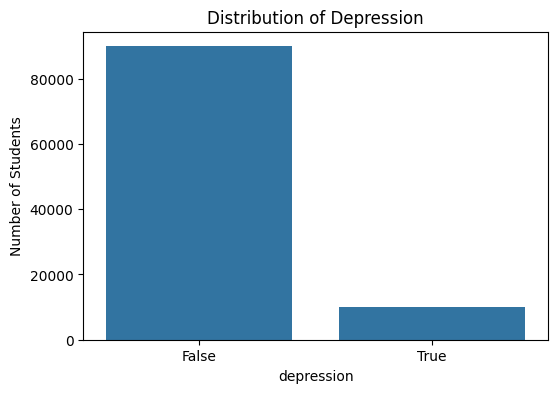

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Depression")
plt.title("Distribution of Depression")
plt.xlabel("depression")
plt.ylabel("Number of Students")
plt.show()

### Depression Distribution Insight

The target variable is imbalanced most of the students don not have depression, This is important because accuracy alone may not be enough to evaluate the model, we should use recall, precision and f1-score to understand model performance better.

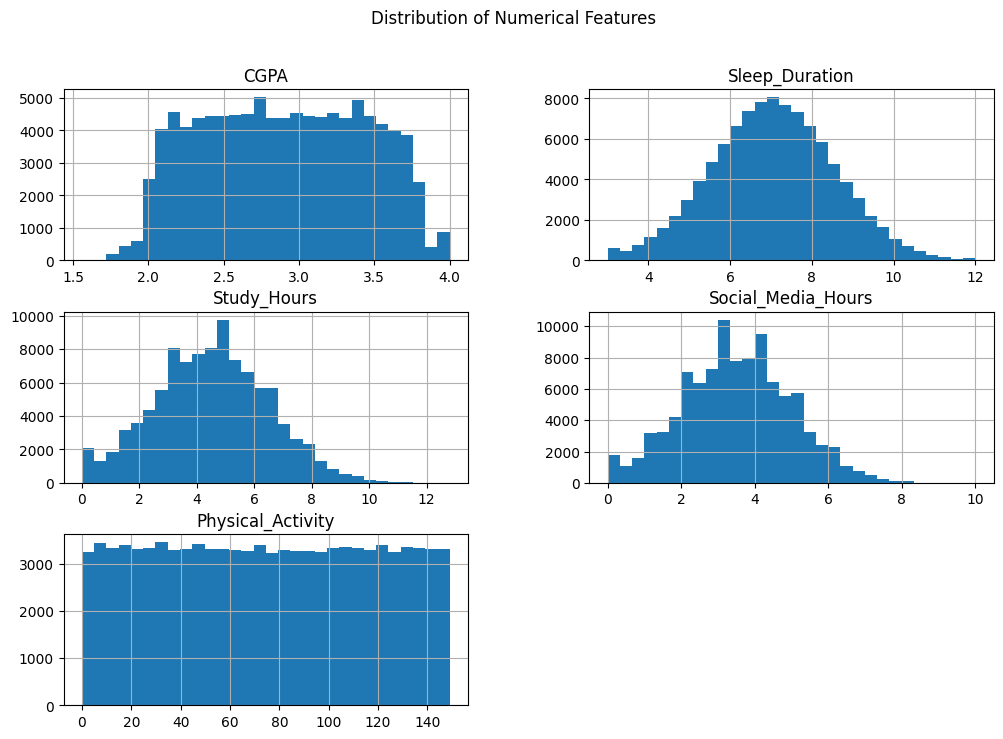

In [8]:
df[["CGPA", "Sleep_Duration", "Study_Hours", 
    "Social_Media_Hours", "Physical_Activity"]].hist(figsize=(12,8),bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [9]:
display(df["Age"].value_counts())
display(df["Stress_Level"].value_counts())

Age
22    14462
24    14393
23    14285
19    14263
21    14207
18    14197
20    14193
Name: count, dtype: int64

Stress_Level
5     24525
4     23326
3     22666
2     13591
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64

### Numerical Distribution Insight 

The numrical features have different distributions and different value ranges.
some features such as CGPA and sleep durations are continuous values while Age and Stress level are discrete age from 18 to 24 and stress level from 1 to 10, also in stress level from 2 to 6 very high comparing to 7, 8, and 9 , 10 are much less common.

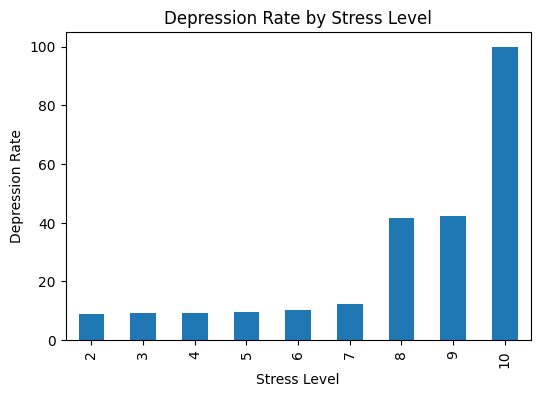

In [10]:
stress_depression=df.groupby("Stress_Level")["Depression"].mean()*100

plt.figure(figsize=(6,4))
stress_depression.plot(kind="bar")
plt.title("Depression Rate by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Depression Rate")
plt.show()

### Stress Level Insight

Students with higher stress levels tend to show a higher depression rate.

This can show us that stress level is important fearture for predicting depression, It also make sense logically because higher stress can be connected to worse mental health.

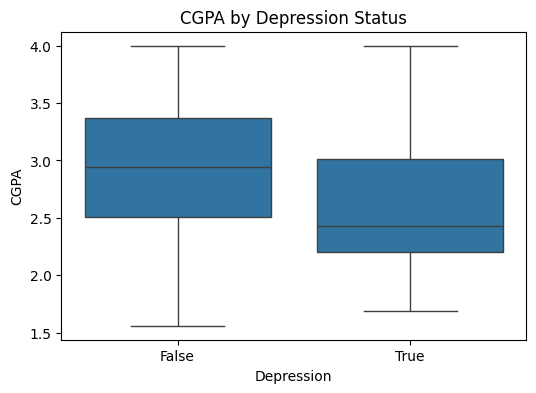

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Depression",y="CGPA")
plt.title("CGPA by Depression Status")
plt.xlabel("Depression")
plt.ylabel("CGPA")
plt.show()

### CGPA by Depression Status Insight

The boxplot shows that students with depression have lower median with nearly 2.9 while the non-derpessed students have median 2.4 , this with other factors can give us important information to predict depression.

In [12]:
department_depression = df.groupby("Department")["Depression"].mean() * 100

department_depression

Department
Arts           10.151015
Business       10.185836
Engineering    10.071297
Medical         9.952915
Science         9.949679
Name: Depression, dtype: float64

### Depression Rate by departments

There is no relations weak relationship between the department and depression 

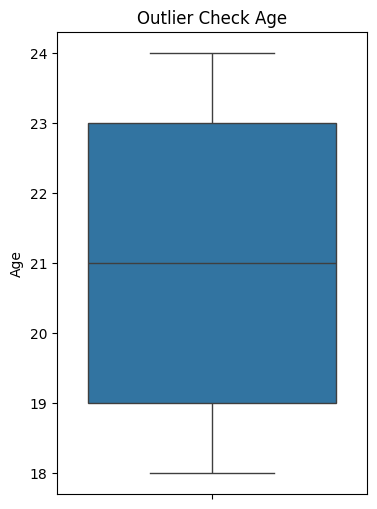

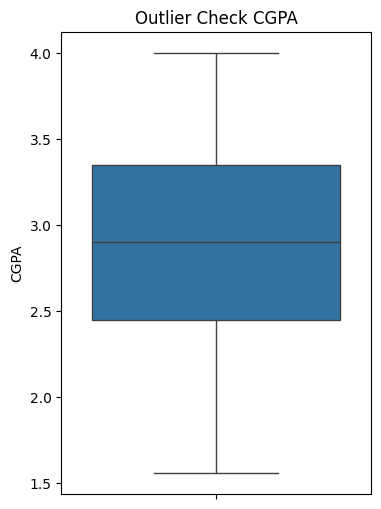

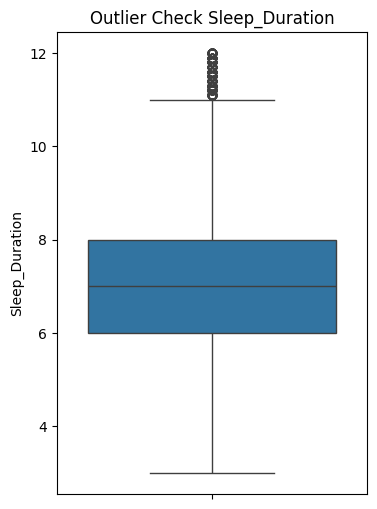

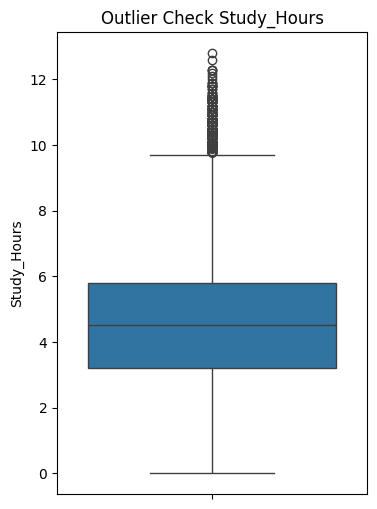

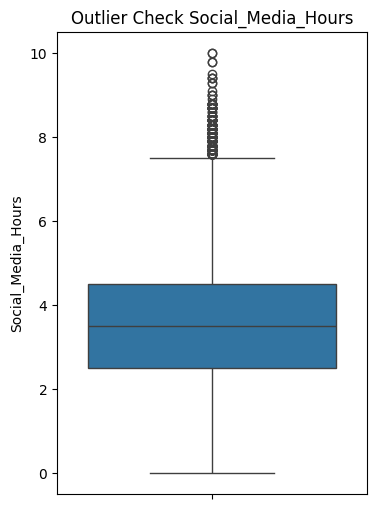

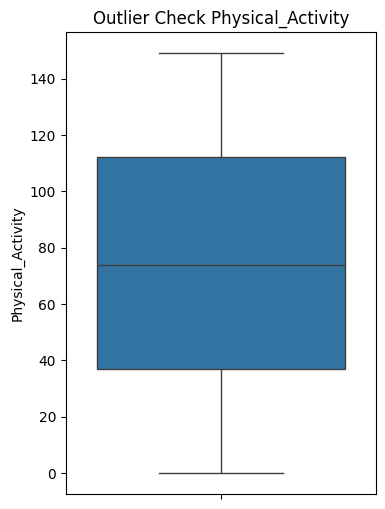

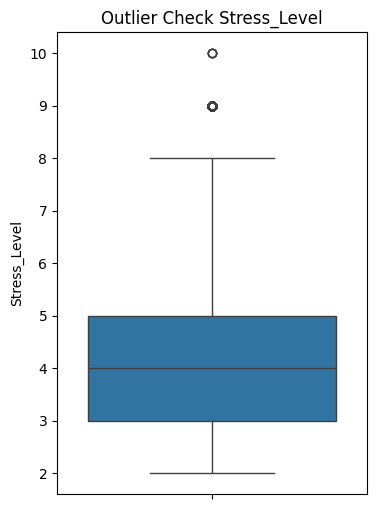

In [13]:
df_clean=df.copy()

numeric_cols=[
    "Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity",
    "Stress_Level"
]
for col in numeric_cols:
    plt.figure(figsize=(4,6))
    sns.boxplot(data=df_clean,y=col)
    plt.title(f"Outlier Check {col}")
    plt.ylabel(col)
    plt.show()

### Outlier Analysis Insight

The Boxplots show some possible outliers in sleep duration, study hours, Social media hours, these outliers are still realistic and it is possible 

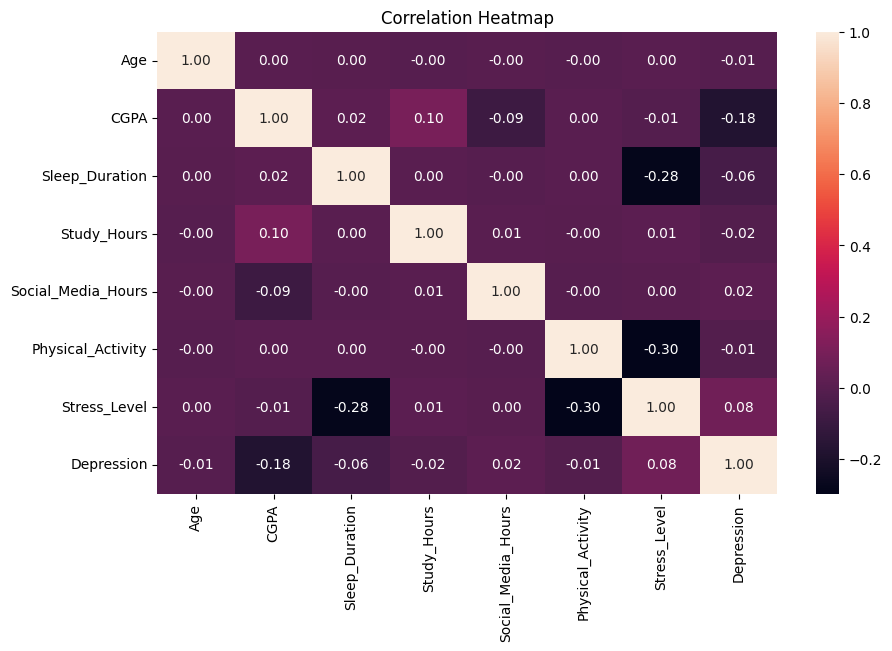

In [14]:
df_corr=df.copy()
df_corr["Depression"]=df_corr["Depression"].astype(int)
corr=df_corr[num_cols+["Depression"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Insight 

The correlations heatmap shows that most numerical features have weak linear relationships with depression.

CGPA has the strongest relationship with depression , with negative correlation this shows that students with higher CGPA have lower depression rate.

Sleep duration and stress level have negative relationships this means students who sleep more tend to have lower stress levels.

In [15]:
df["Sleep_Duration"].unique()


array([ 7.3,  5.5,  5.4,  8.1,  6.8,  6.5,  4.4,  7. ,  4.8,  5.7,  3.8,
        5.1,  7.6,  5.3,  5.9,  7.9,  9.9,  6. , 10.7,  8.4,  4.9, 10.5,
        9.1,  8.5,  6.2,  8.6,  6.3,  7.1,  8. ,  7.4,  4.6,  6.9,  6.4,
        4.5,  9.3,  7.5,  9.6,  7.8,  8.2,  3. ,  4.2,  6.6,  6.1,  5.8,
        6.7,  3.6,  8.8,  8.9,  5.6, 10. ,  4.7,  9. ,  8.3,  7.2,  5.2,
        4. ,  9.2,  9.5,  5. ,  8.7, 10.9,  7.7,  3.4, 11.6,  4.1, 10.3,
        3.1,  3.2, 10.6,  4.3, 10.1,  9.7,  9.4,  9.8,  3.5, 10.2, 10.4,
        3.9,  3.3, 11.8, 10.8, 11.1, 11.2,  3.7, 11. , 11.4, 12. , 11.9,
       11.7, 11.5, 11.3])

In [16]:
df["Social_Media_Hours"].unique()

array([ 3.4,  6. ,  1.8,  4.6,  4.3,  4.1,  3.1,  7.6,  0.3,  3.7,  1.7,
        5.3,  2.8,  2.4,  4.5,  2.5,  3.5,  1.9,  4.8,  3. ,  6.5,  2.9,
        4.2,  2.6,  4.4,  4. ,  1.4,  3.9,  6.1,  6.4,  2.2,  6.3,  3.8,
        2.3,  6.6,  4.9,  1.1,  4.7,  5.4,  0. ,  2. ,  5.6,  3.6,  5.8,
        5.1,  3.2,  5.2,  5.7,  1.5,  2.7,  0.4,  3.3,  1.6,  0.1,  0.2,
        1. ,  5.9,  0.6,  2.1,  7.5,  6.2,  6.9,  5.5,  1.3,  5. ,  0.8,
        0.5,  0.9,  7.3,  0.7,  6.7,  7. ,  8.2,  6.8,  1.2,  7.1,  8. ,
        7.4,  7.2,  7.8,  8.5,  7.7,  9. ,  8.3,  7.9,  9.8,  8.6,  8.1,
        9.4,  9.3,  8.9,  8.4,  8.8,  8.7, 10. ,  9.1,  9.5])

## Here the social media hours and sleep duration features are continues variables , I will change into categories to can deal with it and easily understand it  

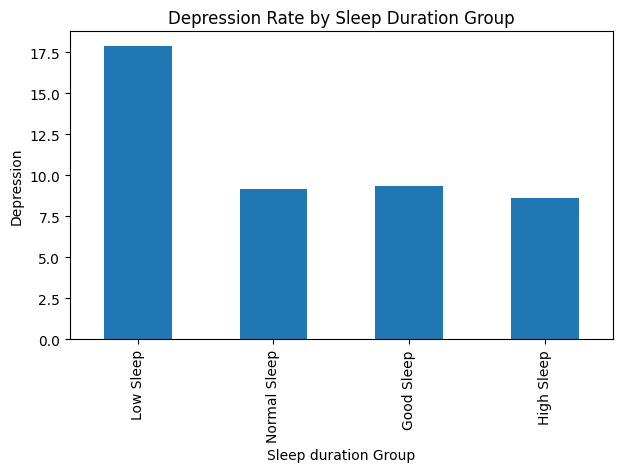

In [17]:
df["Sleep_Group"]=pd.cut(
    df["Sleep_Duration"],
    bins=[0,5,7,9,12]
    ,labels=["Low Sleep","Normal Sleep","Good Sleep","High Sleep"]
)
    
sleep_depression = df.groupby("Sleep_Group")["Depression"].mean()*100

plt.figure(figsize=(7,4))
sleep_depression.plot(kind="bar")
plt.title("Depression Rate by Sleep Duration Group")
plt.xlabel("Sleep duration Group")
plt.ylabel("Depression")
plt.show()

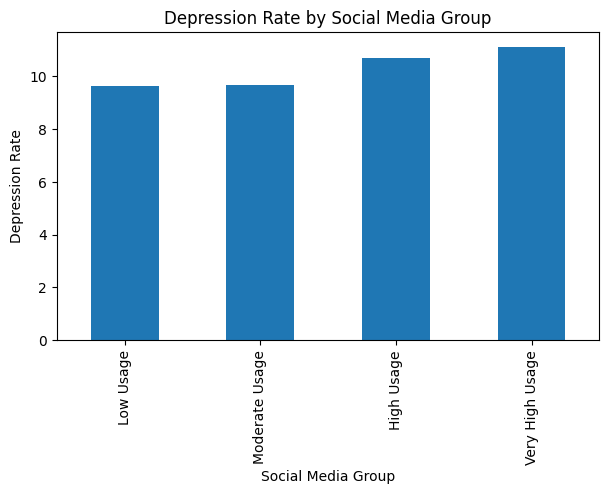

In [18]:
df["Social_Media_Group"]=pd.cut(
    df["Social_Media_Hours"],
    bins=[0,2,4,6,10],
    labels=["Low Usage","Moderate Usage","High Usage","Very High Usage"],
    include_lowest=True
)
social_depression = df.groupby("Social_Media_Group")["Depression"].mean()*100

plt.figure(figsize=(7,4))
social_depression.plot(kind="bar")
plt.title("Depression Rate by Social Media Group")
plt.xlabel("Social Media Group")
plt.ylabel("Depression Rate")
plt.show()

In [19]:
df_clean = df_clean.drop(columns=["Sleep_Group","Social_Media_Group"],errors="ignore")

I have done the Social_Group and Social_Media_Group only to visualize it , The model can learn with the original features so we dropping the features after doing EDA

### Step 3: Data Cleaning 



In [20]:
df_clean=df.copy()
df_clean.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
Sleep_Group           0
Social_Media_Group    0
dtype: int64

In [21]:
df_clean.duplicated().sum()

0

In [22]:
df_clean["Student_ID"].duplicated().sum()

0

In [23]:
df_clean.dtypes

Student_ID               int64
Age                      int64
Gender                     str
Department                 str
CGPA                   float64
Sleep_Duration         float64
Study_Hours            float64
Social_Media_Hours     float64
Physical_Activity        int64
Stress_Level             int64
Depression                bool
Sleep_Group           category
Social_Media_Group    category
dtype: object

In [24]:
df_clean=df_clean.drop(columns=["Student_ID"])

In [25]:
df_clean.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Sleep_Group,Social_Media_Group
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,Good Sleep,Moderate Usage
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,Normal Sleep,High Usage
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,Normal Sleep,Low Usage
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,Good Sleep,High Usage
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,Normal Sleep,High Usage


In [26]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   Age                 100000 non-null  int64   
 1   Gender              100000 non-null  str     
 2   Department          100000 non-null  str     
 3   CGPA                100000 non-null  float64 
 4   Sleep_Duration      100000 non-null  float64 
 5   Study_Hours         100000 non-null  float64 
 6   Social_Media_Hours  100000 non-null  float64 
 7   Physical_Activity   100000 non-null  int64   
 8   Stress_Level        100000 non-null  int64   
 9   Depression          100000 non-null  bool    
 10  Sleep_Group         100000 non-null  category
 11  Social_Media_Group  100000 non-null  category
dtypes: bool(1), category(2), float64(4), int64(3), str(2)
memory usage: 7.2 MB


### Data Cleaning Summary 
no missing values or duplicated rows were found, And we removed the Student_ID column because it only identifier.

There was some outliers like we saw in previous EDA but they are realistic oultiers we will not dealing with it 

## Step 4: Preprocessing 

In [27]:
df_clean=df_clean.drop(
    columns=["Student_ID","Social_Media_Group","Sleep_Group"]
    ,errors="ignore"
)

In [28]:
X=df_clean.drop(columns=["Depression"])
y=df_clean["Depression"].astype(int)

In [29]:
display(X.head())

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6


In [30]:
display(y.head())

0    0
1    0
2    0
3    0
4    0
Name: Depression, dtype: int32

In [31]:
numerical_features=[
    "Age",
    "CGPA",
    "Social_Media_Hours",
    "Sleep_Duration",
    "Study_Hours",
    "Stress_Level",
    "Physical_Activity"
]
categorical_features=["Gender","Department"]

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2 ,random_state=30, stratify=y)

In [33]:
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

X_train (80000, 9)
X_test (20000, 9)
y_train (80000,)
y_test (20000,)


In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),categorical_features)
])


In [35]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [36]:
print("X_test processed shape",X_test_processed.shape)
print("X_train processed shape",X_train_processed.shape)

X_test processed shape (20000, 12)
X_train processed shape (80000, 12)


During the preprocessing step first we dropped three features Student ID because it is identifier it will not provide any important information ,Social_Media_Group and Sleep_Duration_Group also dropped because it was created for EDA, I used OneHotencoding technique to target variable , Gender and Department features to do the modeling in the next steps.

I have done StandardScaler to the Physical Activity feature because it has scale from 0 to 150 while the other features only 0 to 5.

The data was split into training and testing with stratify to make sure the two datasets have same propotion of classes, before fitting the preprocessing steps, we have done this to avoid data leakage because the scaler and encoder learn only from the training data, then the same transformation is applied to the test data.

### Step 5: Dimensionality Reduction Using PCA

In [37]:
from sklearn.decomposition import PCA

full_pca=PCA()
full_pca.fit(X_train_processed)

explained_variance= pd.DataFrame({
    "Principal Component" : range(1,len(full_pca.explained_variance_ratio_)+1),
    "Explained Variance" : full_pca.explained_variance_ratio_,
    "Cumlative Variance" : full_pca.explained_variance_ratio_.cumsum()
})
explained_variance

,Principal Component,Explained Variance,Cumlative Variance
0,1,0.178783,0.178783
1,2,0.143131,0.321914
2,3,0.128087,0.450001
3,4,0.126865,0.576866
4,5,0.125574,0.702440
5,6,0.109418,0.811858
6,7,0.075313,0.887171
7,8,0.031689,0.918860
8,9,0.025511,0.944372
9,10,0.025347,0.969719


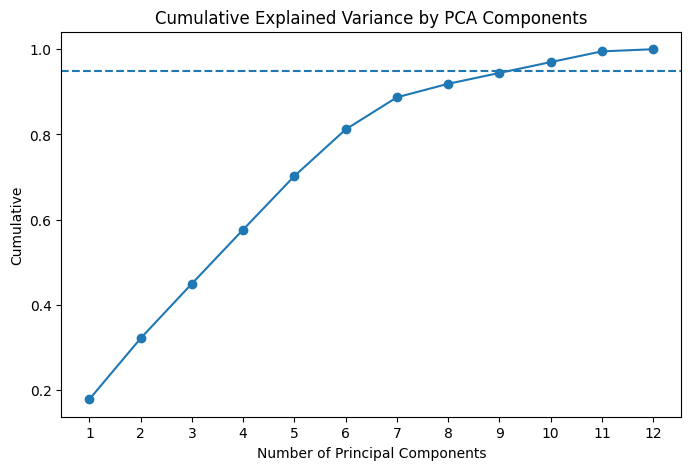

In [38]:
plt.figure(figsize=(8,5))
plt.plot(
    explained_variance["Principal Component"],
    explained_variance["Cumlative Variance"],
    marker="o"    
)

plt.axhline(y=0.95,linestyle="--")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative")
plt.xticks(explained_variance["Principal Component"])
plt.show()

In [39]:
pca_95 = PCA(n_components=0.95)

X_train_pca = pca_95.fit_transform(X_train_processed)
X_test_pca = pca_95.transform(X_test_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Number of PCA components:", pca_95.n_components_)
print("Total explained variance:", pca_95.explained_variance_ratio_.sum())

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)

Original number of features: 12
Number of PCA components: 10
Total explained variance: 0.969718896265755
X_train_pca shape: (80000, 10)
X_test_pca shape: (20000, 10)


### PCA Summary

PCA was applied after preproceesing because PCA requires numerical and scaled features.
I used PCA to check how many features will show 95% variance of the data the result is 10 features give us 96% of variance , I am gonna try both in modeling to see if it is better to reduce number of feature or let it at original 

### Step 6: Modeling and Evaluation

I going to build four models, logisticv regression and randomforest with PCA and without PCA we will see what will give us highest results.

Our focus for the evalution metrics is Recall ,Precision and F1-score because we care more for class 1 , also because the data is imbalanced, accuracy will give us good results because there 90% of class 0. 

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score,confusion_matrix,classification_report

logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

logistic_model.fit(X_train_processed, y_train)
logistic_pred=logistic_model.predict(X_test_processed)

forest_model.fit(X_train_processed, y_train)
forest_pred=forest_model.predict(X_test_processed)

print("Forest Accuracy without PCA: ",accuracy_score(y_test,forest_pred))
print("Precision: ",precision_score(y_test,forest_pred))
print("Recall:",recall_score(y_test,forest_pred))
print("F1-Score:",f1_score(y_test,forest_pred))

print(classification_report(y_test,forest_pred))


print("Logistic Accuracy without PCA: ",accuracy_score(y_test,logistic_pred))
print("Precision: ",precision_score(y_test,logistic_pred))
print("Recall:",recall_score(y_test,logistic_pred))
print("F1-Score:",f1_score(y_test,logistic_pred))

print(classification_report(y_test,logistic_pred))


Forest Accuracy without PCA:  0.88685
Precision:  0.3173216885007278
Recall: 0.10834990059642147
F1-Score: 0.16154131159688773
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     17988
           1       0.32      0.11      0.16      2012

    accuracy                           0.89     20000
   macro avg       0.61      0.54      0.55     20000
weighted avg       0.85      0.89      0.86     20000

Logistic Accuracy without PCA:  0.6259
Precision:  0.16960618506885722
Recall: 0.6978131212723658
F1-Score: 0.27288629737609327
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     17988
           1       0.17      0.70      0.27      2012

    accuracy                           0.63     20000
   macro avg       0.56      0.66      0.51     20000
weighted avg       0.87      0.63      0.70     20000



In [41]:


logistic_pca_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

forest_pca_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

logistic_pca_model.fit(X_train_pca, y_train)
logistic_pca=logistic_pca_model.predict(X_test_pca)

forest_pca_model.fit(X_train_pca, y_train)
forest_pca=forest_pca_model.predict(X_test_pca)

print("Forest Accuracy with PCA: ",accuracy_score(y_test,forest_pca))
print("Precision: ",precision_score(y_test,forest_pca))
print("Recall:",recall_score(y_test,forest_pca))
print("F1-Score:",f1_score(y_test,forest_pca))

print(classification_report(y_test,forest_pca))


print("Logistic Accuracy with PCA: ",accuracy_score(y_test,logistic_pca))
print("Precision: ",precision_score(y_test,logistic_pca))
print("Recall:",recall_score(y_test,logistic_pca))
print("F1-Score:",f1_score(y_test,logistic_pca))

print(classification_report(y_test,logistic_pca))

Forest Accuracy with PCA:  0.8855
Precision:  0.30028735632183906
Recall: 0.10387673956262425
F1-Score: 0.15435745937961595
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     17988
           1       0.30      0.10      0.15      2012

    accuracy                           0.89     20000
   macro avg       0.60      0.54      0.55     20000
weighted avg       0.85      0.89      0.86     20000

Logistic Accuracy with PCA:  0.62545
Precision:  0.16950174930630957
Recall: 0.69831013916501
F1-Score: 0.2727890496068343
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     17988
           1       0.17      0.70      0.27      2012

    accuracy                           0.63     20000
   macro avg       0.56      0.66      0.51     20000
weighted avg       0.87      0.63      0.70     20000



## Best model 

The best model will be based on F1-score and recall, not accuracy alone, because the project focus on predicting depression, detecting actual cases is more important than only achiving high accuracy.

logisitc regression gave us good results for recall which is 70 it actually good because the data are imbalanced and it trained only few samples for class 1 , While the randomforest  achieved higher accuracy, it is recall was lower which means it misses many depressed cases.

When i used PCA with 10 features for the two models gave me results same as without PCA so it has not improve our models. 

## Conclusion and future work
 
 In Conclusion the project helped me learn a lot of things such as doing Explore Data Analysis , finding patterns in data and model building , what is the benefit of the Principal Component Analysis for reducing dimesionality, and what evalution metrics important for imbalanced datasets like we care more about recall for class 1 because they are who we trying to help if there lifestyle leading them to depression.

## Future Work

we may used techniques for handling the imbalance such as smote or ADAYSN these techniques can create synthetic data to make the model train more about depressed class or use more advanced models, also we can do techniques such as UMAP or T-sne for non-linear feature it can make the model sees the data with more relaible way.
